<a href="https://colab.research.google.com/github/abdykaimova/spotify-ML-analysis/blob/main/Spotify_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# настраиваем эстетику для будущих графиков (spotify dark mode vibe)
sns.set_theme(style="darkgrid")
plt.style.use('dark_background')

# генерируем 5000 юзеров Spotify
np.random.seed(42)
n_users = 5000

data = {
    'user_id': range(1, n_users + 1),
    'age': np.random.randint(15, 45, n_users),
    'days_on_platform': np.random.randint(30, 365, n_users),
    'playlists_created': np.random.randint(0, 15, n_users),
    'songs_listened_per_week': np.random.randint(10, 500, n_users),
    'skip_rate_pct': np.random.uniform(0.1, 0.8, n_users), # как часто скипают треки
    'friend_connections': np.random.randint(0, 20, n_users),
    'is_premium': np.random.choice([1, 0], n_users, p=[0.7, 0.3])
}

df = pd.DataFrame(data)

# зашиваем бизнес-логику: кто отменяет подписку?
# гипотеза: если человек много скипает, у него нет друзей в приложении и он не делает плейлисты -> он уйдет
churn_prob = (df['skip_rate_pct'] * 0.4) + ((20 - df['friend_connections'])/20 * 0.3) + ((15 - df['playlists_created'])/15 * 0.3)

# 1 - отменил подписку, 0 - остался с нами
df['churned_next_month'] = np.where((df['is_premium'] == 1) & (churn_prob > 0.65), 1, 0)

# нас интересуют только те, кто СЕЙЧАС платит за премиум
df_premium = df[df['is_premium'] == 1].copy()

# выводим первые 5 строк нашей базы
df_premium.head()

,user_id,age,days_on_platform,playlists_created,songs_listened_per_week,skip_rate_pct,friend_connections,is_premium,churned_next_month
0,1,21,358,0,282,0.105845,1,1,0
1,2,34,195,11,197,0.177249,3,1,0
2,3,43,339,12,364,0.267642,10,1,0
3,4,29,129,9,102,0.254855,2,1,0
6,7,43,266,6,388,0.189195,1,1,0


In [6]:
# 1. смотрим, какой % людей вообще отменяет подписку (Churn Rate)
churn_rate = df_premium['churned_next_month'].mean() * 100
print(f"Overall Churn Rate: {churn_rate:.2f}%\n")

# 2. сравниваем тех, кто ушел, с теми, кто остался
# группируем по колонке churned_next_month и считаем среднее для важных метрик
summary = df_premium.groupby('churned_next_month')[['skip_rate_pct', 'friend_connections', 'playlists_created']].mean()

# переименуем индексы, чтобы было красиво
summary.index = ['Stayed (0)', 'Churned (1)']
print("--- Average User Behavior ---")
print(summary)

Overall Churn Rate: 15.45%

--- Average User Behavior ---
             skip_rate_pct  friend_connections  playlists_created
Stayed (0)        0.414447           10.571820           7.755228
Churned (1)       0.630052            4.386492           3.105066


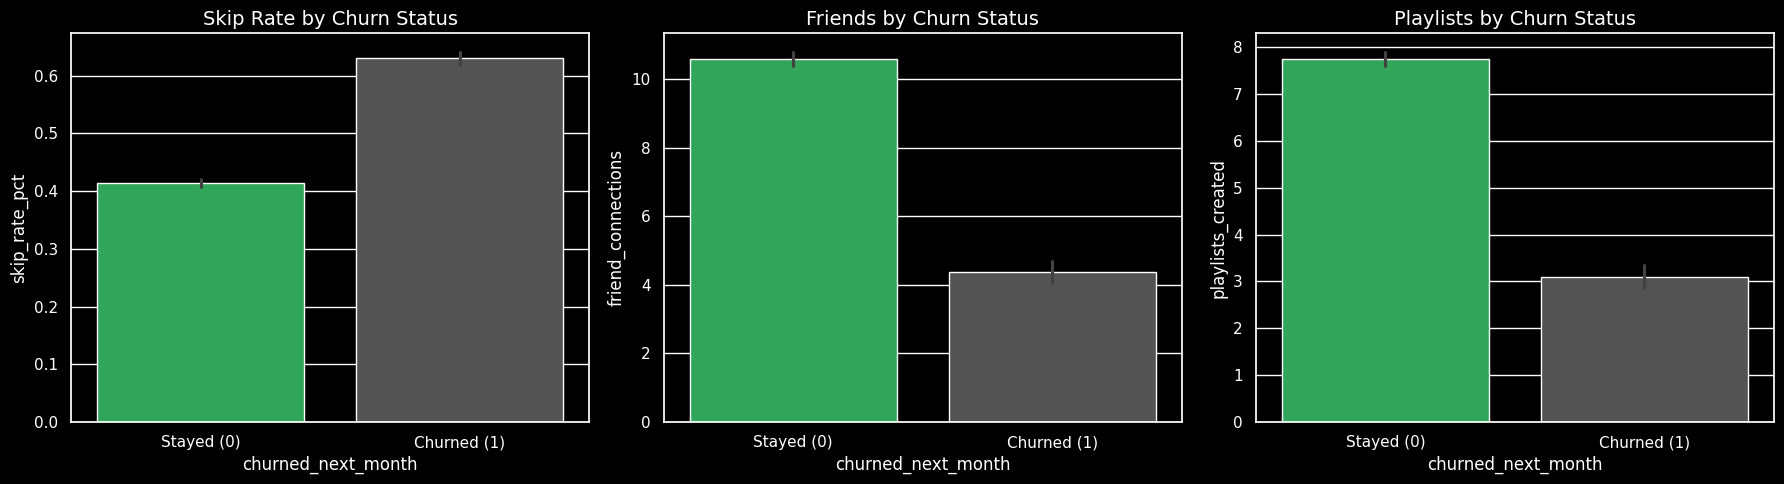

In [8]:
# настраиваем полотно для 3 графиков в ряд
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# цвета в стиле Spotify (зеленый и серый)
spot_colors = ['#1DB954', '#535353']

# График 1: Skip Rate
sns.barplot(x='churned_next_month', y='skip_rate_pct', data=df_premium, ax=axes[0], hue='churned_next_month', palette=spot_colors, legend=False)
axes[0].set_title('Skip Rate by Churn Status', fontsize=14)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Stayed (0)', 'Churned (1)'])

# График 2: Friend Connections
sns.barplot(x='churned_next_month', y='friend_connections', data=df_premium, ax=axes[1], hue='churned_next_month', palette=spot_colors, legend=False)
axes[1].set_title('Friends by Churn Status', fontsize=14)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Stayed (0)', 'Churned (1)'])

# График 3: Playlists Created
sns.barplot(x='churned_next_month', y='playlists_created', data=df_premium, ax=axes[2], hue='churned_next_month', palette=spot_colors, legend=False)
axes[2].set_title('Playlists by Churn Status', fontsize=14)
axes[2].set_xticks([0, 1])
axes[2].set_xticklabels(['Stayed (0)', 'Churned (1)'])

plt.tight_layout()
plt.show()

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. определяем, на что смотрит алгоритм (X) и что он предсказывает (y)
features = ['age', 'days_on_platform', 'playlists_created',
            'songs_listened_per_week', 'skip_rate_pct', 'friend_connections']
X = df_premium[features]
y = df_premium['churned_next_month']

# 2. бьем данные: 80% на обучение, 20% на экзамен
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. вызываем Random Forest и тренируем его!
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. экзамен: просим предсказать отток на тестовых данных
y_pred = model.predict(X_test)

# 5. выводим результаты
print("--- ML Model Performance (Random Forest) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")

# 6. достаем самое вкусное - какие фичи сильнее всего влияют на отток?
importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("--- Top Features Driving Churn ---")
print(importance)

--- ML Model Performance (Random Forest) ---
Accuracy: 98.55%

--- Top Features Driving Churn ---
                   Feature  Importance
4            skip_rate_pct    0.307995
5       friend_connections    0.275763
2        playlists_created    0.267678
1         days_on_platform    0.055726
3  songs_listened_per_week    0.054701
0                      age    0.038138
